# 1. Supervised Learning

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

In [2]:
data = pd.DataFrame({
    'age': [25,45,30,50,28,40,35,55],
    'income': [30000,80000,50000,90000,35000,70000,60000,100000],
    'spending': [80,20,70,10,75,30,50,5],
    'bought': [1,0,1,0,1,0,1,0]
})

In [3]:
X = data[['age','income','spending']]
y = data['bought']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.5


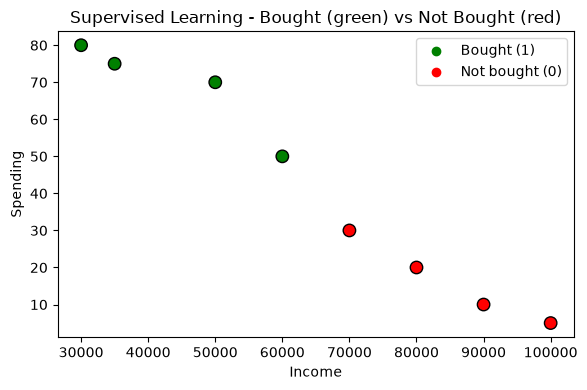

In [5]:
import matplotlib.pyplot as plt

# Supervised: scatter of the labelled data (bought vs not bought)
colors = data['bought'].map({1: 'green', 0: 'red'})

plt.figure(figsize=(6, 4))
plt.scatter(data['income'], data['spending'], c=colors, s=80, edgecolor='k')
plt.xlabel('Income')
plt.ylabel('Spending')
plt.title('Supervised Learning - Bought (green) vs Not Bought (red)')

# legend
plt.scatter([], [], c='green', label='Bought (1)')
plt.scatter([], [], c='red', label='Not bought (0)')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Unsupervised Learning

In [6]:
from sklearn.cluster import KMeans
import pandas as pd

In [7]:
data = pd.DataFrame({
    'age': [25,45,30,50,28,40,35,55],
    'income': [30000,80000,50000,90000,35000,70000,60000,100000],
    'spending': [80,20,70,10,75,30,50,5]
})


In [8]:
kmeans = KMeans(n_clusters=2, random_state=42)
data['cluster'] = kmeans.fit_predict(data)

In [9]:
print(data)

   age  income  spending  cluster
0   25   30000        80        0
1   45   80000        20        1
2   30   50000        70        0
3   50   90000        10        1
4   28   35000        75        0
5   40   70000        30        1
6   35   60000        50        0
7   55  100000         5        1


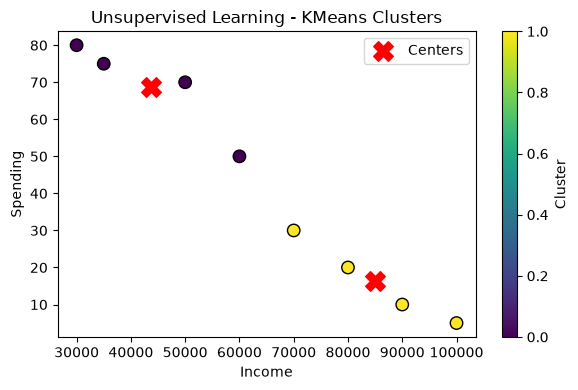

In [10]:
import matplotlib.pyplot as plt

# Unsupervised: scatter coloured by the cluster KMeans discovered
plt.figure(figsize=(6, 4))
scatter = plt.scatter(
    data['income'], data['spending'],
    c=data['cluster'], cmap='viridis', s=80, edgecolor='k'
)

# mark cluster centers
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 1], centers[:, 2], c='red', marker='X', s=200, label='Centers')

plt.xlabel('Income')
plt.ylabel('Spending')
plt.title('Unsupervised Learning - KMeans Clusters')
plt.legend()
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

# 3. Reinforcements Learning

- Environment - KFC, MCD
- Policy - random number between 0 and 1, 0.5 - KFC less - MACD
- Fry Score - reward
- Probabilities are called policy. 

 Goal is to modify the policy so we maximise the reward

In [30]:
import numpy as np

pkfc = 0.5
pmacd = 0.5
lr = 0.1

# rewards
fry_score = {
    "kfc":1,
    "macd":0.7
}


for episode in range(200):
    state = round(np.random.uniform(0, 1), 1)

    # policy
    if state >= 0.5:
        pkfc = pkfc + ( lr * (rewards["kfc"] - pkfc))
    else:
        pmacd = pmacd + (lr * (rewards["macd"] - pmacd))

    # Normalize
    total = pkfc + pmacd
    pkfc = pkfc / total
    pmacd = pmacd / total    

    # print(
    #     f"episode={episode:2d}, "
    #     f"state={state:.1f}, "
    #     f"pkfc={pkfc:.4f}, "
    #     f"pmacd={pmacd:.4f}"
    # )

print("\nFinal Values")
print(f"pkfc    = {pkfc:.4f}")
print(f"pmacd = {pmacd:.4f}")


Final Values
pkfc    = 0.5858
pmacd = 0.4142


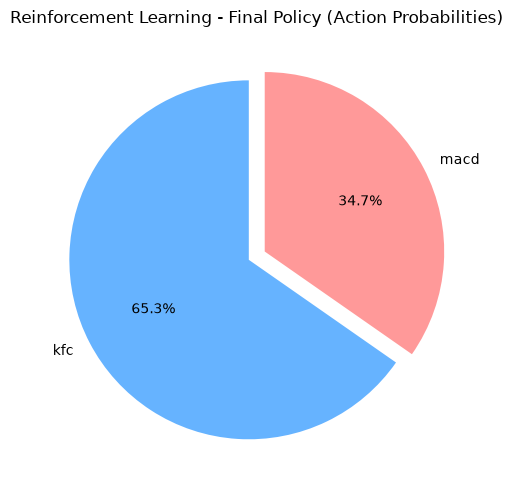

In [31]:
import matplotlib.pyplot as plt

# Reinforcement: final learned policy as a pie chart
labels = ['kfc', 'macd']
probs = [pnorm, psquatch]

plt.figure(figsize=(5, 5))
plt.pie(
    probs, labels=labels, autopct='%1.1f%%',
    colors=['#66b3ff', '#ff9999'], startangle=90, explode=(0.05, 0.05)
)
plt.title('Reinforcement Learning - Final Policy (Action Probabilities)')
plt.tight_layout()
plt.show()